# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

|          Nama          |    NRP     |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [65]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

In [66]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv') # kalo pake kaggle
# df = pd.read_csv('diabetes.csv') # kalo lokal

print(f"Bentuk dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("Tipe data setiap kolom:")
print(df.dtypes)

print("\nStatistik deskriptif dataset:")
display(df.describe())

print("\nJumlah missing value eksplisit (NaN):")
print(df.isnull().sum())

Bentuk dataset: 768 baris, 9 kolom

Tipe data setiap kolom:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Statistik deskriptif dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Jumlah missing value eksplisit (NaN):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


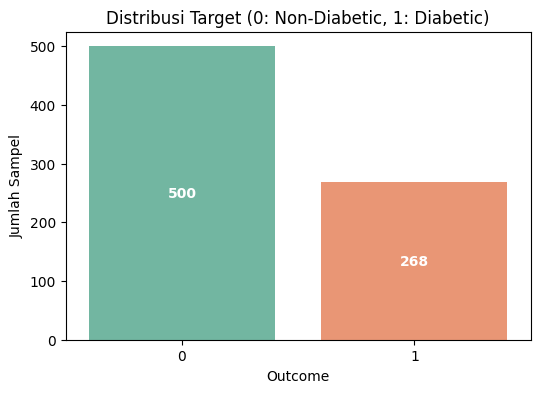

Proporsi kelas target (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [67]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Outcome', hue='Outcome', palette='Set2', legend=False)
plt.title('Distribusi Target (0: Non-Diabetic, 1: Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Sampel')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='white', fontweight='bold')

plt.show()

print("Proporsi kelas target (%):")
print(df['Outcome'].value_counts(normalize=True) * 100)

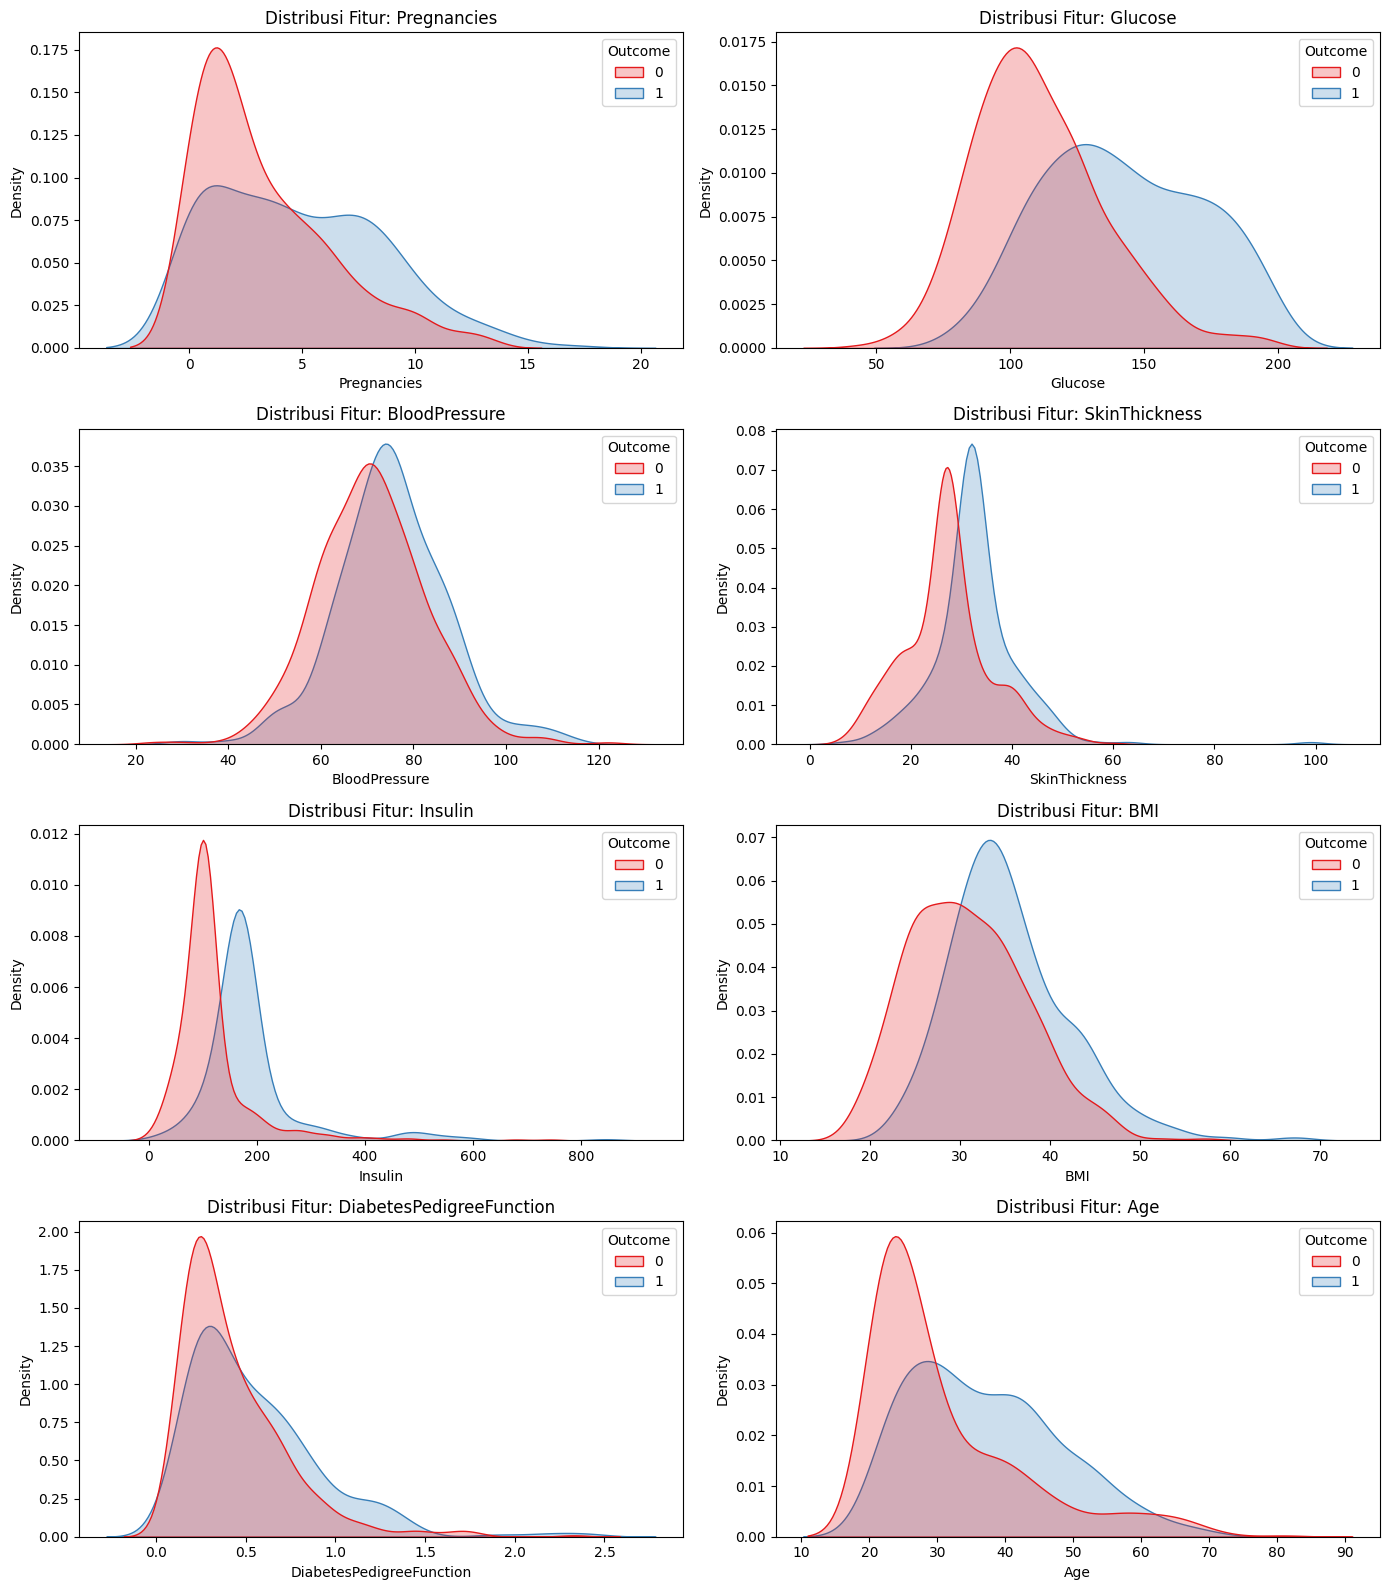

In [68]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.

features = [col for col in df.columns if col != 'Outcome']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue='Outcome', common_norm=False, fill=True, palette='Set1', ax=axes[i])
    axes[i].set_title(f'Distribusi Fitur: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

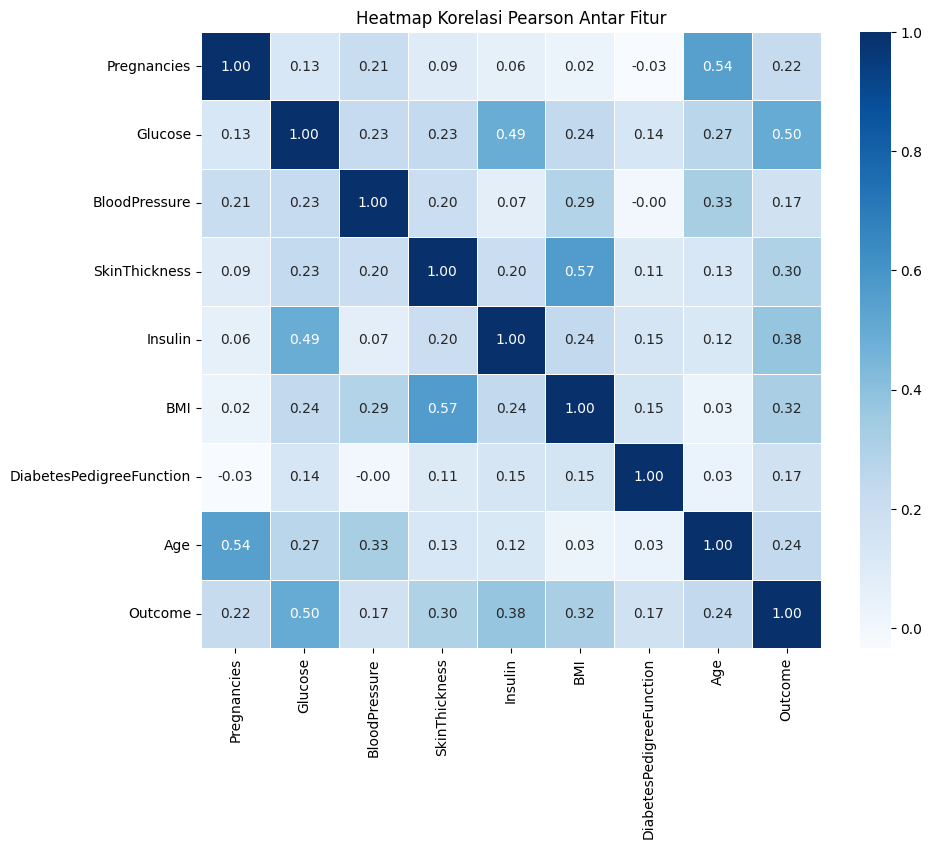

In [69]:
# Tampilkan heatmap korelasi antar fitur.

plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Heatmap Korelasi Pearson Antar Fitur')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [70]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah dan persentase nilai 0 yang tidak valid secara medis:")
zero_stats = pd.DataFrame({
    'Jumlah Nilai 0': (df[zero_cols] == 0).sum(),
    'Persentase (%)': ((df[zero_cols] == 0).mean() * 100).round(2)
})
display(zero_stats)

Jumlah dan persentase nilai 0 yang tidak valid secara medis:


,Jumlah Nilai 0,Persentase (%)
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


In [71]:
# crosscheck nilai minimum yang katanya ada nilai 0 yang ga masuk akal
print("Nilai minimum tiap kolom:")
print(df[zero_cols].min())

Nilai minimum tiap kolom:
Glucose          44.0
BloodPressure    24.0
SkinThickness     7.0
Insulin          14.0
BMI              18.2
dtype: float64


😑

In [72]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

df[zero_cols] = df[zero_cols].replace(0, np.nan) # jika memang ada value 0

In [73]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_medians = X_train[zero_cols].median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Median dari train set yang digunakan:")
print(train_medians)
print("\nSisa missing value pada X_train:", X_train.isnull().sum().sum())
print("Sisa missing value pada X_test:", X_test.isnull().sum().sum())

Median dari train set yang digunakan:
Glucose          117.0
BloodPressure     72.0
SkinThickness     28.0
Insulin          102.5
BMI               32.4
dtype: float64

Sisa missing value pada X_train: 0
Sisa missing value pada X_test: 0


In [74]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [75]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [76]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_gnb = gnb.predict(X_test_scaled)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [77]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [78]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [79]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

models = {
    'Gaussian Naive Bayes': (y_pred_gnb, y_proba_gnb),
    'Logistic Regression': (y_pred_lr, y_proba_lr)
}

metrics_list = []
for name, (pred, proba) in models.items():
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

metrics_df = pd.DataFrame(metrics_list)
display(metrics_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gaussian Naive Bayes,0.727273,0.603448,0.648148,0.625000,0.801667
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429,0.826296


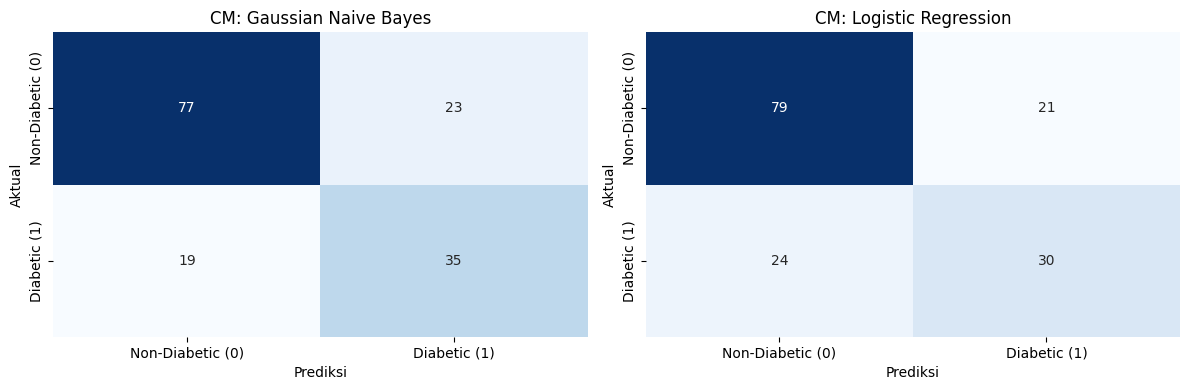

In [80]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'], 
                yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
    ax.set_title(f'CM: {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

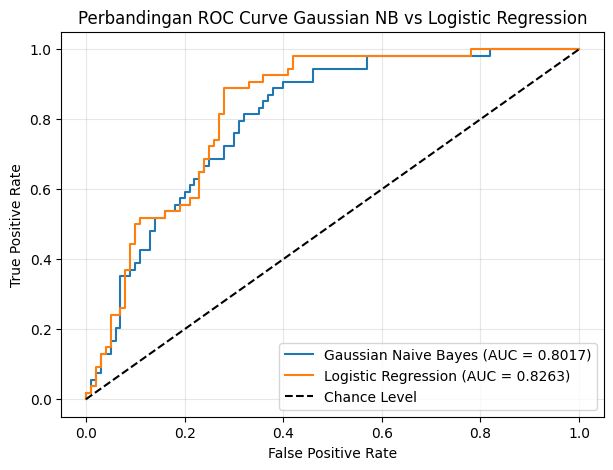

In [81]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(7, 5))

for name, (_, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Perbandingan ROC Curve Gaussian NB vs Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

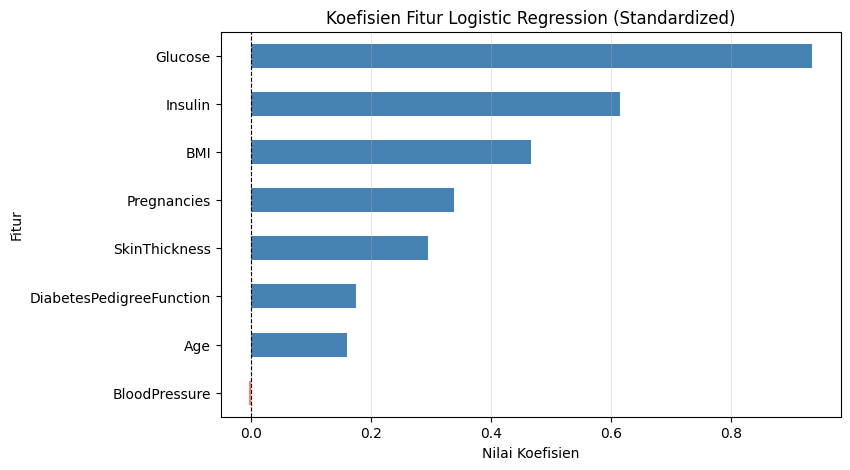

Nilai koefisien setiap fitur:
Glucose                     0.934942
Insulin                     0.614170
BMI                         0.466051
Pregnancies                 0.337228
SkinThickness               0.294976
DiabetesPedigreeFunction    0.174725
Age                         0.159826
BloodPressure              -0.004245
dtype: float64


In [82]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

coefficients = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind='barh', color=(coefficients > 0).map({True: 'steelblue', False: 'salmon'}))
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Koefisien Fitur Logistic Regression (Standardized)')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.grid(axis='x', alpha=0.3)
plt.show()

print("Nilai koefisien setiap fitur:")
print(coefficients.sort_values(ascending=False))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksplorasi awal terhadap 768 sampel data Pima Indians Diabetes, diperoleh temuan dan analisis sebagai berikut:

* Karakteristik Dataset dan Distribusi Target: Dataset terdiri dari 8 fitur numerik dan 1 kolom target (Outcome) dengan proporsi 65.10% non-diabetic dan 34.90% diabetic. Rasio sekitar 2:1 ini menunjukkan kondisi moderately imbalanced, sehingga evaluasi model perlu berfokus pada metrik Precision, Recall, dan ROC-AUC selain akurasi saja.
* Analisis Data Klinis: Ringkasan statistik deskriptif menunjukkan nilai minimum pada fitur fisiologis vital berada di atas angka nol (Glucose min 44.0, BloodPressure min 24.0, SkinThickness min 7.0, Insulin min 14.0, dan BMI min 18.2). Hal ini membuktikan dataset telah melalui tahap pra-pembersihan (pre-cleaned/imputed) sebelum diunduh, sehingga ternyata tidak ada nilai 0 biologis yang tidak valid.
* Analisis Korelasi dan Karakteristik Fitur: Fitur Glucose (r = 0.49) dan BMI (r = 0.31) memiliki korelasi linear positif terkuat terhadap status diabetes, yang ternyata sesuai dengan fakta medis risiko resistensi insulin setelah dilakukannya fact check. Terdapat korelasi antar fitur berkategori sedang antara Pregnancies dan Age (r = 0.54) serta SkinThickness dan BMI (r = 0.54), namun tetap aman dari masalah multikolinearitas serius. Adanya korelasi moderat serta kemiringan (skewness) distribusi fitur seperti Insulin sedikit melanggar asumsi independensi bersyarat pada Gaussian Naive Bayes, sedangkan Logistic Regression dapat mengoptimalkan bobot linear dari seluruh fitur hasil StandardScaler.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulannya eksplorasi awal membuktikan bahwa Pima Indians Diabetes Dataset memiliki struktur data yang bersih tanpa nilai missing eksplisit maupun nilai 0 klinis yang tidak valid. Target klasifikasi memiliki rasio ketimpangan moderat (65.10% berbanding 34.90%), dengan Glucose dan BMI berperan sebagai indikator prediktif paling dominan. Penskalaan fitur menggunakan StandardScaler merupakan tahapan penting untuk menyelaraskan rentang data numerik agar proses pembobotan model berjalan optimal.

Saran:
* Penanganan Ketimpangan Kelas: Uji teknik penyeimbang seperti SMOTE (Synthetic Minority Oversampling Technique) atau penyesuaian parameter bobot kelas (class_weight=balanced pada Logistic Regression) untuk mendongkrak sensitivitas deteksi pada kelas minoritas pasien diabetes.
* Penyesuaian Ambang Batas: Dalam konteks skrining medis, ambang probabilitas klasifikasi dapat diturunkan dari 0.5 ke angka yang lebih rendah guna memaksimalkan Recall agar meminimalkan risiko pasien diabetes yang tidak terdiagnosis.
* Feature Engineering dan Selection: Pertimbangkan untuk mentransformasi fitur yang berkorelasi sedang seperti rasio Glucose terhadap Insulin atau rasio BMI terhadap Age untuk mempertajam sinyal biologis bagi model prediktif.